# Met Office Datasets - Radar Observations

The UK Weather Radar Network is designed to provide continuous, real-time rainfall data over almost the whole of the UK land area and inshore waters. The data can provide valuable information for immediate emergency response in times of extreme weather conditions, as well as providing data to flood planners when managing future risk. In addition to rainfall data the radar network provides observations for the Met Office numerical weather prediction system, in the form of Doppler measurements of wind and a novel technique for using radars to measure of changes in humidity.

Further info
* [Met Office Radar Systems](https://www.metoffice.gov.uk/research/weather/observations-research/radar-systems)

Radar data can be accessed in a variety of ways:
* * [Map of latest radar observations](https://weather.metoffice.gov.uk/maps-and-charts/rainfall-radar-forecast-map#?layer=rainfall-rate)
  * [CEDA Catalog](https://catalogue.ceda.ac.uk/uuid/82adec1f896af6169112d09cc1174499/)
  * [AWS Sustainable Data Initiative](https://registry.opendata.aws/met-office-uk-radar-observations/)

Today we'll be using the [snapshot](https://github.com/mlcast-community/mlcast-datasets) that has been prepared for use in an ML workflow by the MLcast community.

In [3]:
import pathlib
import datetime

In [4]:
import xarray

In [5]:
import intake


In [6]:
import pandas

In [3]:
import intake_xarray

## Prepare data subset
For this activity we are going to prepare a subset of the data for our exploration. We will open the remote dataset using 

Further reading 
* [Intake Catalog docs](https://intake.readthedocs.io/en/latest/catalog.html)
* [Zarr docs](https://zarr.readthedocs.io/en/stable/)

In [4]:
cat = intake.open_catalog("https://raw.githubusercontent.com/mlcast-community/mlcast-datasets/main/src/mlcast_datasets/catalog/catalog.yml")

In [7]:
cat['precipitation']


precipitation:
  args:
    path: https://raw.githubusercontent.com/mlcast-community/mlcast-datasets/main/src/mlcast_datasets/catalog/precipitation/catalog.yml
  description: Precipitation-related datasets from RADKLIM, IT-DPC and other sources
  driver: intake.catalog.local.YAMLFileCatalog
  metadata:
    catalog_dir: https://raw.githubusercontent.com/mlcast-community/mlcast-datasets/main/src/mlcast_datasets/catalog


In [8]:
list(cat['precipitation'])

['radklim_hourly',
 'radklim_5_minutes',
 'dmi_10_minutes',
 'it_dpc_sri_5min',
 'uk_metoffice_5min',
 'be_rmi_radclim_mfb_5min']

In [9]:
cat['precipitation']['uk_metoffice_5min']

In [11]:
uk_radar_ds = cat['precipitation']['uk_metoffice_5min'].to_dask()

In [17]:
uk_radar_ds.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array('2005-07-05T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2005-07-05
Attributes:
    long_name:      Time
    standard_name:  time

In [19]:
uk_radar_ds.time[-1]

<xarray.DataArray 'time' ()> Size: 8B
array('2025-12-31T23:55:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2025-12-31T23:55:00
Attributes:
    long_name:      Time
    standard_name:  time

In [42]:
uk_radar_202406_ds = uk_radar_ds.sel(time=slice('2024-06-11 00:00',',2024-06-12 00:00'))
uk_radar_202406_ds

<xarray.Dataset> Size: 4GB
Dimensions:        (time: 289, y: 2175, x: 1725, missing_times: 100404)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2024-06-11 ... 2024-06-12
  * y              (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
  * x              (x) float64 14kB -4.045e+05 -4.035e+05 ... 1.318e+06 1.32e+06
    lat            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
    lon            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 803kB 2005-07-05T06:40:00 ....
Data variables:
    crs            float32 4B ...
    RR             (time, y, x) float32 4GB dask.array<chunksize=(1, 2175, 1725), meta=np.ndarray>
Attributes:
    title:                      UK Met Office C-band rain radar 1 km composite
    license:                    OGL-UK-3.0
    history:                    Created at 2026-02-16T22:33:20+01:00
    mlcast_created_on:          2026-02-16T22:33:20+01:00
    mlcast_created_by:          Gabriele Franch <franch@fbk.eu>
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...
    mlcast_dataset_version:     0.1.0
    mlcast_dataset_identifier:  UK-METOFFICE-RADAR
    consistent_timestep_start:  2005-07-05T00:00
    base_frequencies:           5min:2005-07-05T00:00/None

In [27]:
radar_dir = pathlib.Path('/gws/ssde/j25a/mmh_storage/uk_radar/')

In [56]:
fname_template = 'uk_radar_{dt.year:04d}{dt.month:02d}{dt.day:02d}.nc'

In [57]:
for dt1 in pandas.date_range('2024-06-01 00:00','2024-08-01 00:00',freq='1D'):
    day_radar_path = radar_dir / fname_template.format(dt=dt1)
    print(day_radar_path)
    uk_radar_ds.sel(time=slice(dt1, dt1 + datetime.timedelta(days=1))).to_netcdf(day_radar_path)

/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240601.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240602.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240603.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240604.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240605.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240606.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240607.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240608.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240609.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240610.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240611.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240612.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240613.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240614.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240615.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240616.nc
/gws/ssde/j25a/mmh_storage/uk_radar/uk_radar_20240617.nc
/gws/ssde/j25a/mmh_storage/uk_r

### Load the local subset

In [1]:
radar_dir.iterdir()

NameError: name 'radar_dir' is not defined

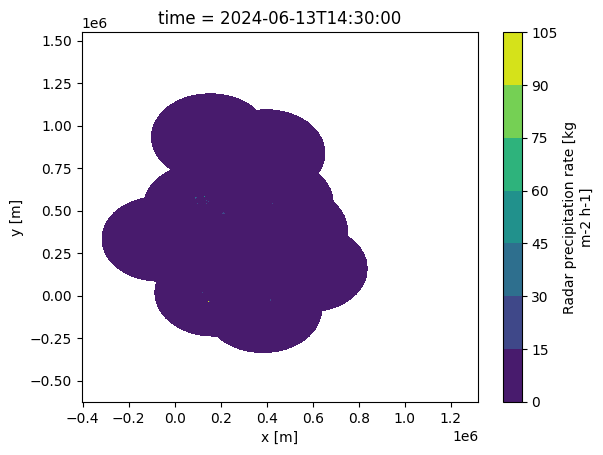

In [38]:
uk_radar_202406_ds.sel(time=datetime.datetime(2024,6,13,14,30))['RR'].plot.contourf()

In [29]:
uk_radar_local = xarray.open_zarr(radar_dir)
uk_radar_local

<xarray.Dataset> Size: 76MB
Dimensions:        (time: 1, y: 2175, x: 1725, missing_times: 100404)
Coordinates:
  * time           (time) datetime64[ns] 8B 2024-06-01
  * y              (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
  * x              (x) float64 14kB -4.045e+05 -4.035e+05 ... 1.318e+06 1.32e+06
    lat            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
    lon            (y, x) float64 30MB dask.array<chunksize=(2175, 1725), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 803kB 2005-07-05T06:40:00 ....
Data variables:
    RR             (time, y, x) float32 15MB dask.array<chunksize=(1, 2175, 1725), meta=np.ndarray>
    crs            float32 4B ...
Attributes:
    title:                      UK Met Office C-band rain radar 1 km composite
    license:                    OGL-UK-3.0
    history:                    Created at 2026-02-16T22:33:20+01:00
    mlcast_created_on:          2026-02-16T22:33:20+01:00
    mlcast_created_by:          Gabriele Franch <franch@fbk.eu>
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...
    mlcast_dataset_version:     0.1.0
    mlcast_dataset_identifier:  UK-METOFFICE-RADAR
    consistent_timestep_start:  2005-07-05T00:00
    base_frequencies:           5min:2005-07-05T00:00/None

In [33]:
uk_radar_local.sel(time=datetime.datetime(2024,6,13,14,30))

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."